In [1]:
import praw
import time
import threading
from datetime import datetime
from influxdb_client import InfluxDBClient, Point, WritePrecision
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import re

# ✅ Download VADER Lexicon (if not installed)
nltk.download("vader_lexicon")

# ✅ Initialize Sentiment Analyzer
sia = SentimentIntensityAnalyzer()

# ✅ Initialize Reddit API (Replace with your credentials)
reddit = praw.Reddit(
    client_id='X3QMqyEUMxQyWX3X5-HOUw',
    client_secret='nSdFvZgy5SR4x4RIHV6gmhj2EPUBkQ',
    user_agent='windows:SentimentScope:v1.0 (by kalyan_kumar_m_)'
)

# ✅ Initialize InfluxDB (Replace with your details)
INFLUXDB_URL = "http://localhost:8086"
INFLUXDB_TOKEN = "TsexJtD3FBPYkUZmd-dl-zJFLEP-Ga5Wi73jhxJdmImshez6cTHHv_4L4Qupl5fMmiH0c9tB-FZpiAjrWXBSlw=="
INFLUXDB_ORG = "RedditAnalysis"
INFLUXDB_BUCKET = "sentiment_data"

# ✅ Connect to InfluxDB
influx_client = InfluxDBClient(url=INFLUXDB_URL, token=INFLUXDB_TOKEN, org=INFLUXDB_ORG)
write_api = influx_client.write_api()

# ✅ Define Keywords for Filtering Subtopics
FILTER_KEYWORDS = ["therapy", "depression", "anxiety", "mental health", "stress"]

# ✅ Function to Fetch & Store Reddit Data
def fetch_reddit_data():
    subreddits = ["depression", "mentalhealth", "Anxiety", "selfimprovement"]  # Add relevant subreddits
    
    for subreddit in subreddits:
        for post in reddit.subreddit(subreddit).new(limit=10):  # Fetch latest posts
            # Check if the post contains relevant subtopics
            if any(re.search(rf"\b{keyword}\b", post.title + ' ' + post.selftext, re.IGNORECASE) for keyword in FILTER_KEYWORDS):
                # Analyze sentiment
                sentiment_score = sia.polarity_scores(post.selftext)["compound"]
                sentiment_label = (
                    "positive" if sentiment_score > 0.05 else
                    "negative" if sentiment_score < -0.05 else "neutral"
                )

                # Get additional metadata
                post_data = {
                    "post_id": post.id,
                    "timestamp": datetime.utcfromtimestamp(post.created_utc).isoformat(),
                    "title": post.title,
                    "text": post.selftext,
                    "sentiment_label": sentiment_label,
                    "sentiment_score": sentiment_score,
                    "upvote_ratio": post.upvote_ratio,
                    "num_comments": post.num_comments,
                    "subreddit": subreddit,
                }

                # Store data in InfluxDB
                point = (
                    Point("reddit_sentiment")
                    .tag("subreddit", subreddit)
                    .tag("sentiment_label", sentiment_label)
                    .field("post_id", post.id)
                    .field("timestamp", post_data["timestamp"])
                    .field("title", post.title)
                    .field("text", post.selftext)
                    .field("sentiment_score", sentiment_score)
                    .field("upvote_ratio", post.upvote_ratio)
                    .field("num_comments", post.num_comments)
                    .time(datetime.utcfromtimestamp(post.created_utc), WritePrecision.NS)
                )

                write_api.write(bucket=INFLUXDB_BUCKET, org=INFLUXDB_ORG, record=point)
                print(f"✅ Stored: {post.title[:30]}... (Sentiment: {sentiment_label})")
        
        time.sleep(10)  # Prevent API rate limiting

# ✅ Run Fetching in a Separate Thread
stop_event = threading.Event()

def start_reddit_collection():
    while not stop_event.is_set():
        fetch_reddit_data()
        time.sleep(30)  # Fetch every 30 seconds

# ✅ Start Data Collection
collection_thread = threading.Thread(target=start_reddit_collection)
collection_thread.start()

# ✅ Stop Script When User Presses ENTER
input("Press ENTER to stop collecting data...\n")
stop_event.set()
collection_thread.join()  # Wait for the thread to stop
print("🛑 Data collection stopped.")


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\kalya\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\kalya\AppData\Local\Temp\ipykernel_3296\1157222411.py:54: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  "timestamp": datetime.utcfromtimestamp(post.created_utc).isoformat(),
C:\Users\kalya\AppData\Local\Temp\ipykernel_3296\1157222411.py:76: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  .time(datetime.utcfromtimestamp(post.created_utc), WritePrecision.NS)


✅ Stored: Time to Deal With It... (Sentiment: negative)
✅ Stored: I don't know what to do anymor... (Sentiment: positive)
✅ Stored: What are some unusual causes d... (Sentiment: negative)
✅ Stored: Lost a lot... (Sentiment: positive)
✅ Stored: Feeling Trapped In a Dreary Ex... (Sentiment: negative)
✅ Stored: I don’t know who I am... (Sentiment: positive)
✅ Stored: Question ?... (Sentiment: negative)
✅ Stored: Wierd stuff... (Sentiment: negative)
✅ Stored: How do I keep my long distance... (Sentiment: positive)
✅ Stored: I've been honestly wondering t... (Sentiment: negative)
✅ Stored: Does anyone else feel anxiety ... (Sentiment: negative)
✅ Stored: I don't feel grown up... (Sentiment: negative)
✅ Stored: Just had EMTs come check my ou... (Sentiment: negative)
✅ Stored: anxiety to anger... (Sentiment: negative)
✅ Stored: How do you manage your anxiety... (Sentiment: neutral)
✅ Stored: OCD or legit concerns?... (Sentiment: negative)
✅ Stored: Panicking on xanax... (Sentiment: negative)


✅ TF-IDF Vectorizer Saved Successfully!

🔹 Random Forest Accuracy: 77.29%
              precision    recall  f1-score   support

          -1       0.74      0.70      0.72      1655
           0       0.80      0.90      0.84      1656
           1       0.78      0.72      0.75      1656

    accuracy                           0.77      4967
   macro avg       0.77      0.77      0.77      4967
weighted avg       0.77      0.77      0.77      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


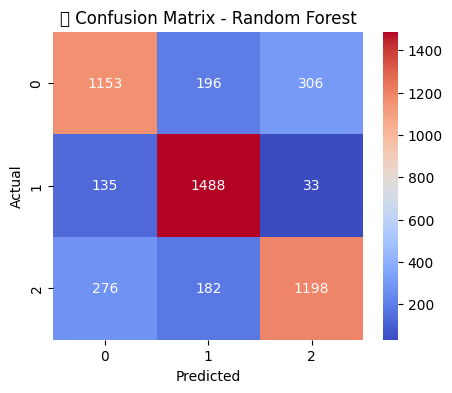


🔹 Naive Bayes Accuracy: 70.79%
              precision    recall  f1-score   support

          -1       0.65      0.78      0.71      1655
           0       0.84      0.55      0.67      1656
           1       0.69      0.79      0.74      1656

    accuracy                           0.71      4967
   macro avg       0.73      0.71      0.70      4967
weighted avg       0.73      0.71      0.70      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


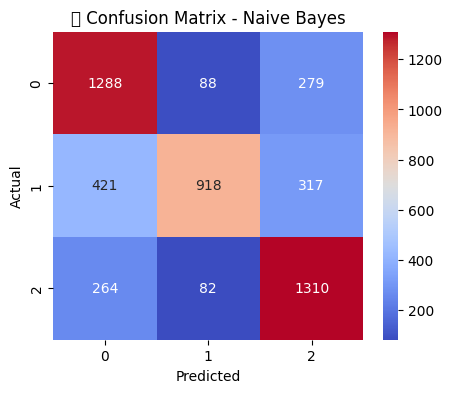


🔹 Svm Accuracy: 87.52%
              precision    recall  f1-score   support

          -1       0.88      0.82      0.85      1655
           0       0.88      0.97      0.92      1656
           1       0.87      0.83      0.85      1656

    accuracy                           0.88      4967
   macro avg       0.88      0.88      0.87      4967
weighted avg       0.88      0.88      0.87      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


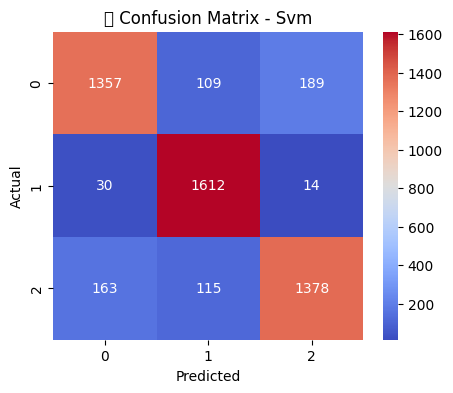


🔹 Logistic Regression Accuracy: 85.30%
              precision    recall  f1-score   support

          -1       0.87      0.79      0.83      1655
           0       0.84      0.95      0.89      1656
           1       0.86      0.82      0.84      1656

    accuracy                           0.85      4967
   macro avg       0.85      0.85      0.85      4967
weighted avg       0.85      0.85      0.85      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


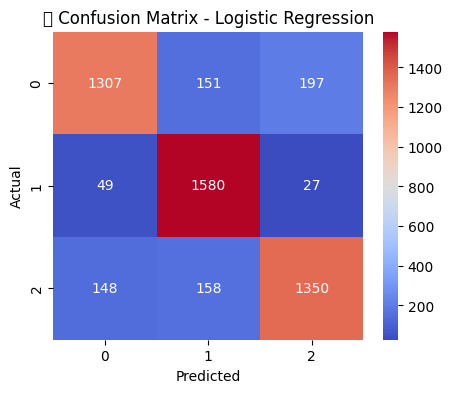


🔹 Knn Accuracy: 37.45%
              precision    recall  f1-score   support

          -1       0.83      0.06      0.12      1655
           0       0.35      0.99      0.51      1656
           1       0.92      0.07      0.13      1656

    accuracy                           0.37      4967
   macro avg       0.70      0.37      0.26      4967
weighted avg       0.70      0.37      0.26      4967



C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128313 (\N{SMALL BLUE DIAMOND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


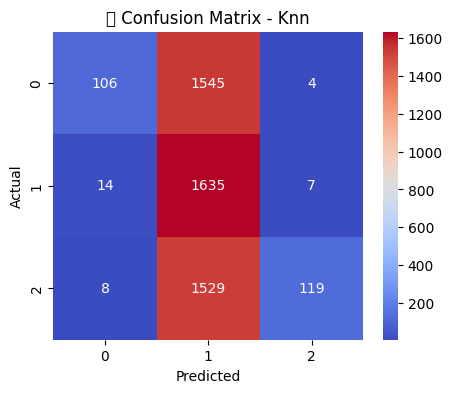

✅ All Text Sentiment Models Trained & Saved Successfully!


In [2]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from sklearn.feature_extraction.text import TfidfVectorizer

# Load dataset
df = pd.read_csv("D:\\final year project\\Reddit_Data.csv")

# Rename columns for consistency
df.rename(columns={'clean_comment': 'post_text', 'category': 'sentiment_label'}, inplace=True)

df.dropna(subset=['post_text', 'sentiment_label'], inplace=True)

# Handle Class Imbalance
X_text = df['post_text']
y_text = df['sentiment_label']
undersample = RandomUnderSampler(random_state=42)
X_text_resampled, y_text_resampled = undersample.fit_resample(X_text.values.reshape(-1, 1), y_text)
X_text_resampled = X_text_resampled.flatten()

# Convert text to numerical features using TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_resampled_tfidf = vectorizer.fit_transform(X_text_resampled)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled_tfidf, y_text_resampled, test_size=0.2, random_state=42, stratify=y_text_resampled
)

# Save TF-IDF Vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
print("✅ TF-IDF Vectorizer Saved Successfully!")

# Machine Learning Models (Optimized)
models = {
    "random_forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "naive_bayes": MultinomialNB(),
    "svm": SVC(kernel='linear', probability=True),
    "logistic_regression": LogisticRegression(max_iter=200, n_jobs=-1),
    "knn": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Save each trained model
    model_filename = f"{name}_model.pkl"
    joblib.dump(model, model_filename)
    
    y_pred = model.predict(X_test)

    print(f"\n🔹 {name.replace('_', ' ').title()} Accuracy: {np.mean(y_pred == y_test) * 100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="coolwarm", fmt="d")
    plt.title(f"🔹 Confusion Matrix - {name.replace('_', ' ').title()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

print("✅ All Text Sentiment Models Trained & Saved Successfully!")


In [14]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix

# 🔹 Set dataset path
dataset_path = "D:\\final year project\\Images"  # Ensure your dataset is uploaded here

# 🔹 Image Preprocessing
img_size = (128, 128)  # Resize images to 128x128
batch_size = 32

train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# 🔹 Build CNN Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')  # 3 classes (positive, negative, neutral)
])

# 🔹 Compile Model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 🔹 Train Model
epochs = 10
history = model.fit(train_generator, validation_data=val_generator, epochs=epochs)

# 🔹 Evaluate Model
val_labels = val_generator.classes
val_pred = np.argmax(model.predict(val_generator), axis=1)

print("\n🔹 Classification Report:")
print(classification_report(val_labels, val_pred, target_names=train_generator.class_indices.keys()))

print("\n🔹 Confusion Matrix:")
print(confusion_matrix(val_labels, val_pred))

# 🔹 Save Model
model.save("sentiment_cnn_model.h5")

# 🔹 Predict Sentiment for New Image
def predict_sentiment(image_path):
    from tensorflow.keras.preprocessing import image

    img = image.load_img(image_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    sentiment = np.argmax(prediction)

    labels = {v: k for k, v in train_generator.class_indices.items()}
    return labels[sentiment]

# Example usage:
image_path = "D:\\final year project\\1.jpg"  # Upload a test image here
print(f"\n🔹 Predicted Sentiment: {predict_sentiment(image_path)}")


Found 3896 images belonging to 3 classes.
Found 973 images belonging to 3 classes.


C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


Epoch 1/10


C:\Users\kalya\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:120: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


122/122 ━━━━━━━━━━━━━━━━━━━━ 34s 261ms/step - accuracy: 0.3452 - loss: 1.1213 - val_accuracy: 0.3638 - val_loss: 1.0952
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 32s 260ms/step - accuracy: 0.3480 - loss: 1.0973 - val_accuracy: 0.3638 - val_loss: 1.0949
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 33s 263ms/step - accuracy: 0.3765 - loss: 1.0948 - val_accuracy: 0.3638 - val_loss: 1.0950
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 33s 260ms/step - accuracy: 0.3693 - loss: 1.0921 - val_accuracy: 0.3577 - val_loss: 1.0932
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 33s 261ms/step - accuracy: 0.3825 - loss: 1.0789 - val_accuracy: 0.3607 - val_loss: 1.0975
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 33s 267ms/step - accuracy: 0.4309 - loss: 1.0461 - val_accuracy: 0.3577 - val_loss: 1.1069
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 34s 272ms/step - accuracy: 0.4644 - loss: 1.0018 - val_accuracy: 0.3720 - val_loss: 1.1561
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 34s 273ms/step - accuracy: 0.5368 - loss: 0.9244 - val


🔹 Classification Report:
              precision    recall  f1-score   support

    Negative       0.32      0.26      0.29       290
     Neutral       0.38      0.49      0.43       354
    positive       0.34      0.29      0.31       329

    accuracy                           0.35       973
   macro avg       0.35      0.35      0.34       973
weighted avg       0.35      0.35      0.35       973


🔹 Confusion Matrix:
[[ 76 127  87]
 [ 82 172 100]
 [ 78 156  95]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step

🔹 Predicted Sentiment: Negative
